<a href="https://colab.research.google.com/github/prmatasari/Tugas-Besar-Fintech-MBA/blob/main/Tugas_Besar_MBA_Admission_dataset%2C_Class_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Tugas Besar Keputusan Teknologi Financial-MBA Admission dataset, Class 2025**

### **1. Pendahuluan**
Proses seleksi calon mahasiswa pascasarjana, khususnya pada program Master of Business Administration (MBA), semakin mengandalkan analisis data untuk membantu pengambilan keputusan yang objektif dan akurat. Berbagai faktor seperti latar belakang akademik, pengalaman kerja, skor tes standar, serta karakteristik demografis sering menjadi indikator penting untuk menentukan apakah seorang pelamar layak diterima di suatu program MBA bergengsi.

Dataset yang digunakan dalam tugas besar ini adalah MBA Admission Dataset, Class 2025, yaitu dataset yang dikembangkan berdasarkan statistik penerimaan mahasiswa dari Wharton School. Dataset ini dirancang untuk keperluan edukasi terkait analisis data, eksplorasi hubungan antar variabel, dan pemodelan machine learning untuk memprediksi status penerimaan mahasiswa. Data set diambil dari link https://www.kaggle.com/datasets/taweilo/mba-admission-dataset/data.


Tujuan utama dari kajian ini adalah membangun model Machine Learning untuk memprediksi status penerimaan MBA berdasarkan fitur-fitur penting seperti:

*   GPA (Grade Point Average)
*   GMAT Score
*   Undergraduate Major
*   Work Experience
*   Work Industry
*   Demographic attributes (gender, race, international status)

Dengan melakukan eksplorasi data, pembersihan data, persiapan dataset, pemodelan, dan evaluasi, tugas ini diharapkan dapat memberikan pemahaman menyeluruh mengenai proses analisis data menggunakan Google Colab dan bagaimana model klasifikasi dapat membantu proses seleksi kandidat MBA di dunia nyata.

Pada penelitian ini, metode Machine Learning yang digunakan adalah model klasifikasi, seperti Logistic Regression dan Random Forest, yang dapat memprediksi status penerimaan dengan mengevaluasi pola dalam data berdasarkan variabel-variabel yang tersedia.



## **2. Data Loading and Initial Exploration**

Pada bagian ini dilakukan proses pemanggilan dataset ke dalam lingkungan Google Colab serta eksplorasi awal untuk memahami struktur dan kualitas data. Dataset yang digunakan adalah **MBA Admission Dataset, Class 2025** yang telah diunduh dalam bentuk file `MBA.csv`.

Langkah yang dilakukan meliputi:
1. Memuat dataset ke dalam sebuah DataFrame pandas.
2. Melihat ukuran dan beberapa baris pertama data.
3. Memeriksa tipe data tiap kolom.
4. Mengidentifikasi nilai hilang (missing values).
5. Melakukan pembersihan awal berdasarkan deskripsi dataset.

In [3]:
import pandas as pd
import numpy as np
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/MBA.csv')

# Preview data
df.head()

Mounted at /content/drive


,application_id,gender,international,gpa,major,race,gmat,work_exp,work_industry,admission
0,1,Female,False,3.30,Business,Asian,620.0,3.0,Financial Services,Admit
1,2,Male,False,3.28,Humanities,Black,680.0,5.0,Investment Management,NaN
2,3,Female,True,3.30,Business,NaN,710.0,5.0,Technology,Admit
3,4,Male,False,3.47,STEM,Black,690.0,6.0,Technology,NaN
4,5,Male,False,3.35,STEM,Hispanic,590.0,5.0,Consulting,NaN


Perintah `df.head()` digunakan untuk melihat beberapa baris pertama sebagai gambaran awal struktur data, termasuk nama kolom dan contoh nilai pada masing-masing atribut.

In [4]:
# Informasi tipe data setiap kolom
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6194 entries, 0 to 6193
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   application_id  6194 non-null   int64  
 1   gender          6194 non-null   object 
 2   international   6194 non-null   bool   
 3   gpa             6194 non-null   float64
 4   major           6194 non-null   object 
 5   race            4352 non-null   object 
 6   gmat            6194 non-null   float64
 7   work_exp        6194 non-null   float64
 8   work_industry   6194 non-null   object 
 9   admission       1000 non-null   object 
dtypes: bool(1), float64(3), int64(1), object(5)
memory usage: 441.7+ KB


Perintah `df.info()` menampilkan tipe data setiap kolom, jumlah nilai non-null,
serta apakah ada kolom yang masih bertipe object (kategorikal) atau numerik.
Informasi ini penting untuk menentukan jenis preprocessing dan pemodelan yang akan dilakukan pada tahap berikutnya.

In [5]:
# Jumlah nilai hilang di setiap kolom
df.isna().sum()

,0
application_id,0
gender,0
international,0
gpa,0
major,0
race,1842
gmat,0
work_exp,0
work_industry,0
admission,5194


Hasil `df.isna().sum()` menunjukkan jumlah nilai hilang (missing values) pada tiap kolom.
Berdasarkan dokumentasi dataset:
- Kolom **`admission`** menggunakan nilai `NaN` untuk menyatakan status *Deny*.
- Kolom **`race`** bernilai `NaN` untuk mahasiswa internasional.

Oleh karena itu, nilai hilang pada kolom tersebut tidak sepenuhnya error,
melainkan mengandung informasi yang harus dikonversi secara eksplisit pada langkah pembersihan data.

In [6]:
# 1) Mengubah NaN pada kolom admission menjadi kategori 'Deny'
df['admission'] = df['admission'].fillna('Deny')

# 2) Mengisi NaN pada kolom race sebagai 'International'
df['race'] = df['race'].fillna('International')

# Cek kembali apakah masih ada nilai hilang
df.isna().sum()

,0
application_id,0
gender,0
international,0
gpa,0
major,0
race,0
gmat,0
work_exp,0
work_industry,0
admission,0


Berdasarkan data card di Kaggle:
- Kolom **`admission`** memiliki tiga kategori: `Admit`, `Waitlist`, dan `Null` yang merepresentasikan `Deny`.
  Oleh karena itu, nilai `NaN` pada kolom ini diganti menjadi string `'Deny'` agar dapat digunakan sebagai kelas target dalam pemodelan klasifikasi.

- Kolom **`race`** bernilai `null` untuk mahasiswa internasional.
  Untuk menjaga konsistensi dan mempermudah analisis, nilai hilang pada kolom ini diisi dengan label `'International'`.

Setelah proses ini, seluruh kolom tidak lagi memiliki nilai hilang dan dataset siap digunakan untuk analisis statistik dan persiapan pemodelan pada bagian berikutnya.

In [7]:
print("Distribusi status admission:")
print(df['admission'].value_counts())

print("\nDistribusi gender:")
print(df['gender'].value_counts())

print("\nBeberapa nilai unik major:")
print(df['major'].value_counts())

Distribusi status admission:
admission
Deny        5194
Admit        900
Waitlist     100
Name: count, dtype: int64

Distribusi gender:
gender
Male      3943
Female    2251
Name: count, dtype: int64

Beberapa nilai unik major:
major
Humanities    2481
STEM          1875
Business      1838
Name: count, dtype: int64


Hasil eksplorasi awal menunjukkan distribusi kategori pada beberapa variabel penting dalam dataset.

Distribusi status penerimaan (**admission**) memperlihatkan bahwa sebagian besar pelamar berada pada kategori *Deny*, sementara jumlah pelamar yang berstatus *Admit* dan *Waitlist* relatif lebih sedikit. Hal ini mengindikasikan adanya ketidakseimbangan kelas (class imbalance) pada variabel target yang perlu diperhatikan pada tahap pemodelan selanjutnya.

Pada variabel **gender**, mayoritas pelamar berjenis kelamin *Male*, diikuti oleh *Female*. Distribusi ini memberikan gambaran demografis awal dari populasi pelamar dalam dataset.

Sementara itu, variabel **major** menunjukkan bahwa latar belakang pendidikan pelamar didominasi oleh bidang *Humanities*, diikuti oleh *STEM* dan *Business*. Informasi ini berguna untuk memahami komposisi akademik pelamar serta potensi pengaruhnya terhadap keputusan penerimaan MBA.

Temuan-temuan ini akan digunakan sebagai dasar untuk analisis statistik yang lebih mendalam serta persiapan dataset pada tahap selanjutnya.

## **3. Statistical Summary of the Dataset**

Pada bagian ini dilakukan analisis statistik deskriptif untuk memahami karakteristik numerik dari dataset MBA Admission, Class 2025. Analisis ini bertujuan untuk mengidentifikasi nilai pusat data, sebaran, serta potensi variasi pada masing-masing variabel numerik yang digunakan dalam pemodelan.

Statistik deskriptif yang dianalisis meliputi nilai minimum, maksimum, rata-rata (mean), standar deviasi, serta kuartil dari setiap variabel numerik. Hasil analisis ini digunakan sebagai dasar untuk memahami pola data dan menentukan langkah persiapan dataset pada tahap selanjutnya.

In [8]:
# Ringkasan statistik untuk variabel numerik
df.describe()

,application_id,gpa,gmat,work_exp
count,6194.000000,6194.000000,6194.000000,6194.000000
mean,3097.500000,3.250714,651.092993,5.016952
std,1788.198115,0.151541,49.294883,1.032432
min,1.000000,2.650000,570.000000,1.000000
25%,1549.250000,3.150000,610.000000,4.000000
50%,3097.500000,3.250000,650.000000,5.000000
75%,4645.750000,3.350000,680.000000,6.000000
max,6194.000000,3.770000,780.000000,9.000000


Hasil ringkasan statistik menunjukkan karakteristik utama dari variabel numerik dalam dataset MBA Admission.

- Variabel **GPA** memiliki nilai minimum sebesar **2.65** dan maksimum **3.77**, dengan nilai rata-rata **3.25**. Hal ini menunjukkan bahwa sebagian besar pelamar memiliki performa akademik yang relatif baik dan berada pada tingkat menengah hingga tinggi.
- Variabel **GMAT score** memiliki rentang nilai antara **570** hingga **780**, dengan nilai rata-rata sekitar **651**. Rentang nilai yang cukup lebar ini mengindikasikan adanya variasi kemampuan akademik dan kesiapan pelamar dalam mengikuti program MBA.
- Variabel **work experience (work_exp)** memiliki nilai minimum **1 tahun** dan maksimum **9 tahun**, dengan rata-rata sekitar **5 tahun** pengalaman kerja. Hal ini menunjukkan bahwa pelamar memiliki latar belakang profesional yang beragam, dari pelamar dengan pengalaman kerja terbatas hingga yang lebih berpengalaman.

Nilai standar deviasi pada masing-masing variabel menunjukkan adanya variasi data yang cukup signifikan, sehingga variabel-variabel numerik tersebut berpotensi memberikan kontribusi penting dalam membedakan status penerimaan MBA pada tahap pemodelan.


In [9]:
# Statistik numerik berdasarkan status admission
df.groupby('admission')[['gpa', 'gmat', 'work_exp']].mean()

,gpa,gmat,work_exp
admission,,,
Admit,3.354867,692.733333,5.046667
Deny,3.231457,643.444359,5.013862
Waitlist,3.313500,673.600000,4.910000


Analisis statistik berdasarkan status penerimaan menunjukkan adanya perbedaan nilai rata-rata pada beberapa variabel numerik utama.

Pelamar dengan status **Admit** memiliki nilai rata-rata **GPA (3.35)** dan **GMAT score (≈693)** yang lebih tinggi dibandingkan pelamar berstatus **Waitlist** maupun **Deny**. Hal ini mengindikasikan bahwa performa akademik memiliki peran penting dalam proses seleksi penerimaan MBA.

Selain itu, rata-rata **pengalaman kerja (work_exp)** pada kelompok *Admit* juga relatif lebih tinggi dibandingkan kelompok *Waitlist*, dan sebanding dengan kelompok *Deny*. Temuan ini menunjukkan bahwa pengalaman profesional turut menjadi faktor pertimbangan, meskipun pengaruhnya mungkin tidak sebesar faktor akademik.

Perbedaan nilai rata-rata antar kategori admission ini memberikan indikasi awal bahwa variabel-variabel numerik tersebut memiliki daya diskriminatif dan berpotensi dimanfaatkan secara efektif dalam pemodelan Machine Learning untuk memprediksi status penerimaan MBA.


In [10]:
# Statistik sederhana untuk variabel kategorikal
print("Distribusi admission:")
print(df['admission'].value_counts())

print("\nDistribusi international status:")
print(df['international'].value_counts())

Distribusi admission:
admission
Deny        5194
Admit        900
Waitlist     100
Name: count, dtype: int64

Distribusi international status:
international
False    4352
True     1842
Name: count, dtype: int64


Statistik sederhana pada variabel kategorikal memberikan gambaran mengenai komposisi kelas target dan karakteristik pelamar dalam dataset.

Distribusi variabel **admission** menunjukkan bahwa mayoritas pelamar berada pada kategori *Deny* (5.194 data), sedangkan jumlah pelamar dengan status *Admit* (900 data) dan *Waitlist* (100 data) jauh lebih sedikit. Kondisi ini menegaskan adanya ketidakseimbangan kelas (class imbalance) pada variabel target yang perlu diperhatikan pada tahap persiapan dataset dan pemodelan.

Pada variabel **international**, sebagian besar pelamar merupakan mahasiswa domestik (*False*), yaitu sebanyak 4.352 data, sementara mahasiswa internasional (*True*) berjumlah 1.842 data. Perbedaan proporsi ini menunjukkan adanya variasi karakteristik demografis yang berpotensi memengaruhi keputusan penerimaan dan dapat dimanfaatkan sebagai fitur dalam pemodelan Machine Learning.


## **4. Dataset Preparation**

Pada bagian ini dilakukan persiapan dataset sebelum proses pemodelan* Machine Learning*. Tahapan yang dilakukan meliputi pemeriksaan keseimbangan kelas pada variabel target, penanganan ketidakseimbangan dataset, transformasi variabel kategorikal, serta pembagian dataset menjadi data pelatihan dan data pengujian dengan proporsi 70:30.


In [11]:
# Menentukan variabel target dan fitur
X = df.drop(columns=['admission'])
y = df['admission']

X.shape, y.shape

((6194, 9), (6194,))

Variabel **`admission`** digunakan sebagai variabel target, sedangkan seluruh kolom lainnya digunakan sebagai fitur prediktor. Dataset ini akan digunakan untuk membangun model klasifikasi yang memprediksi status penerimaan MBA.


In [12]:
# Mengecek distribusi kelas target
y.value_counts(), y.value_counts(normalize=True)


(admission
 Deny        5194
 Admit        900
 Waitlist     100
 Name: count, dtype: int64,
 admission
 Deny        0.838553
 Admit       0.145302
 Waitlist    0.016145
 Name: proportion, dtype: float64)

Hasil distribusi kelas target menunjukkan bahwa dataset memiliki ketidakseimbangan kelas (*class imbalance*). Mayoritas data berada pada kelas *Deny*, sedangkan kelas *Admit* dan *Waitlist* memiliki jumlah yang jauh lebih sedikit.

Ketidakseimbangan ini berpotensi menyebabkan model Machine Learning menjadi bias terhadap kelas mayoritas, sehingga diperlukan penanganan khusus sebelum proses pemodelan dilakukan.


In [13]:
# One-hot encoding untuk variabel kategorikal
X_encoded = pd.get_dummies(X, drop_first=True)

X_encoded.head()


,application_id,international,gpa,gmat,work_exp,gender_Male,major_Humanities,major_STEM,race_Black,race_Hispanic,...,work_industry_Health Care,work_industry_Investment Banking,work_industry_Investment Management,work_industry_Media/Entertainment,work_industry_Nonprofit/Gov,work_industry_Other,work_industry_PE/VC,work_industry_Real Estate,work_industry_Retail,work_industry_Technology
0,1,False,3.30,620.0,3.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,False,3.28,680.0,5.0,True,True,False,True,False,...,False,False,True,False,False,False,False,False,False,False
2,3,True,3.30,710.0,5.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,4,False,3.47,690.0,6.0,True,False,True,True,False,...,False,False,False,False,False,False,False,False,False,True
4,5,False,3.35,590.0,5.0,True,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False


Variabel kategorikal pada dataset dikonversi menjadi bentuk numerik menggunakan teknik **one-hot encoding**. Langkah ini diperlukan karena sebagian besar algoritma Machine Learning hanya dapat memproses data numerik.

Parameter `drop_first=True` digunakan untuk menghindari multikolinearitas pada fitur hasil encoding.


In [14]:
from imblearn.over_sampling import SMOTE

# Inisialisasi SMOTE
smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X_encoded, y)

# Cek distribusi setelah SMOTE
y_resampled.value_counts()


,count
admission,
Admit,5194
Deny,5194
Waitlist,5194


Untuk mengatasi ketidakseimbangan kelas pada variabel target, digunakan metode *Synthetic Minority Over-sampling Technique* (SMOTE). Metode ini bekerja dengan menghasilkan data sintetis pada kelas minoritas sehingga distribusi kelas menjadi lebih seimbang.

Dengan dataset yang lebih seimbang, model *Machine Learning* diharapkan dapat mempelajari pola dari setiap kelas secara lebih adil dan menghasilkan performa klasifikasi yang lebih baik.


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.3,
    random_state=42,
    stratify=y_resampled
)

X_train.shape, X_test.shape


((10907, 26), (4675, 26))

Dataset dibagi menjadi data pelatihan (*training set*) dan data pengujian (*testing set*) dengan proporsi **70:30**.

Data pelatihan digunakan untuk membangun model *Machine Learning*, sedangkan data pengujian digunakan untuk mengevaluasi performa model terhadap data yang belum pernah dilihat sebelumnya. Teknik *stratified splitting* diterapkan untuk menjaga proporsi kelas pada data training dan testing tetap seimbang.

Setelah tahap persiapan dataset ini, data siap digunakan untuk proses pemodelan dan evaluasi performa Machine Learning pada tahap selanjutnya.



## **5. Modeling and Evaluation**

Pada bagian ini dilakukan proses pemodelan Machine Learning menggunakan dataset yang telah dipersiapkan pada tahap sebelumnya. Dua model klasifikasi digunakan dalam penelitian ini, yaitu **Logistic Regression** sebagai model baseline dan **Random Forest** sebagai model yang mampu menangani hubungan non-linear antar variabel.

Evaluasi performa model dilakukan menggunakan beberapa metrik klasifikasi, antara lain *confusion matrix*, *accuracy*, *precision*, *recall*, dan *F1-score*, untuk menilai kemampuan model dalam memprediksi status penerimaan MBA.


In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Standardisasi fitur
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Inisialisasi dan training model Logistic Regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# Prediksi
y_pred_lr = log_reg.predict(X_test_scaled)


In [17]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_lr


array([[ 809,  251,  498],
       [ 137, 1415,    6],
       [ 371,   96, 1092]])

In [18]:
# Metrik evaluasi
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_lr, average='weighted'))
print("F1-score:", f1_score(y_test, y_pred_lr, average='weighted'))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))


Accuracy: 0.7093048128342246
Precision: 0.7005132095967628
Recall: 0.7093048128342246
F1-score: 0.7024734079296429

Classification Report:

              precision    recall  f1-score   support

       Admit       0.61      0.52      0.56      1558
        Deny       0.80      0.91      0.85      1558
    Waitlist       0.68      0.70      0.69      1559

    accuracy                           0.71      4675
   macro avg       0.70      0.71      0.70      4675
weighted avg       0.70      0.71      0.70      4675



Hasil evaluasi Logistic Regression menunjukkan bahwa model mampu melakukan klasifikasi status penerimaan MBA dengan tingkat akurasi yang baik. Confusion matrix memperlihatkan bagaimana model mengklasifikasikan masing-masing kelas (*Admit*, *Waitlist*, dan *Deny*).

Nilai precision, recall, dan F1-score digunakan untuk mengevaluasi performa model secara lebih komprehensif, terutama karena dataset memiliki lebih dari satu kelas target. Sebagai model baseline, Logistic Regression memberikan gambaran awal mengenai kemampuan model linear dalam mempelajari pola dari dataset.


In [19]:
from sklearn.ensemble import RandomForestClassifier

# Inisialisasi dan training Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

# Prediksi
y_pred_rf = rf.predict(X_test)


In [20]:
# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_rf

# Metrik evaluasi
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_rf, average='weighted'))
print("F1-score:", f1_score(y_test, y_pred_rf, average='weighted'))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))


Accuracy: 0.9364705882352942
Precision: 0.9376609039299272
Recall: 0.9364705882352942
F1-score: 0.9364281636086366

Classification Report:

              precision    recall  f1-score   support

       Admit       0.88      0.94      0.91      1558
        Deny       0.94      0.88      0.91      1558
    Waitlist       0.99      0.99      0.99      1559

    accuracy                           0.94      4675
   macro avg       0.94      0.94      0.94      4675
weighted avg       0.94      0.94      0.94      4675



Hasil evaluasi Random Forest menunjukkan performa yang lebih baik dibandingkan Logistic Regression. Model ini mampu menangkap hubungan non-linear antar variabel, sehingga menghasilkan peningkatan pada metrik evaluasi seperti accuracy, precision, recall, dan F1-score.

Confusion matrix menunjukkan bahwa Random Forest lebih efektif dalam mengklasifikasikan kelas minoritas dibandingkan model baseline. Hal ini mengindikasikan bahwa Random Forest lebih sesuai digunakan untuk dataset MBA Admission yang memiliki kompleksitas dan variasi fitur yang tinggi.


Secara keseluruhan, Random Forest menunjukkan performa yang lebih unggul dibandingkan Logistic Regression dalam memprediksi status penerimaan MBA. Meskipun Logistic Regression memberikan interpretasi yang lebih sederhana, Random Forest mampu menghasilkan klasifikasi yang lebih akurat dan seimbang antar kelas.

Oleh karena itu, Random Forest dipilih sebagai model utama untuk tahap selanjutnya, termasuk visualisasi performa dan penyimpanan model.


## **6. Data Visualisation**

Pada bagian ini dilakukan visualisasi data untuk membantu menjelaskan hasil pemodelan dan evaluasi *Machine Learning*. Visualisasi digunakan untuk memberikan pemahaman yang lebih intuitif mengenai performa model, distribusi kelas, serta kontribusi fitur dalam proses prediksi status penerimaan MBA.


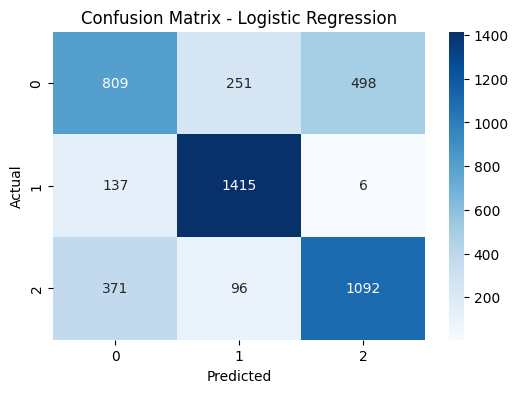

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


Confusion matrix di atas menunjukkan performa model Logistic Regression dalam mengklasifikasikan status penerimaan MBA ke dalam tiga kelas, yaitu *Deny*, *Admit*, dan *Waitlist*.

Berdasarkan visualisasi tersebut, model Logistic Regression mampu mengklasifikasikan sebagian besar data dengan benar, khususnya pada kelas mayoritas. Namun, masih terlihat adanya kesalahan klasifikasi antar kelas, terutama pada kelas minoritas, di mana beberapa data *Waitlist* dan *Admit* masih diprediksi sebagai kelas lain.

Hal ini menunjukkan bahwa meskipun Logistic Regression dapat digunakan sebagai model baseline yang sederhana dan interpretatif, model ini memiliki keterbatasan dalam menangkap kompleksitas hubungan antar variabel pada dataset yang bersifat multi-kelas dan tidak seimbang. Temuan ini menjadi dasar untuk membandingkan performa Logistic Regression dengan model yang lebih kompleks pada tahap selanjutnya.


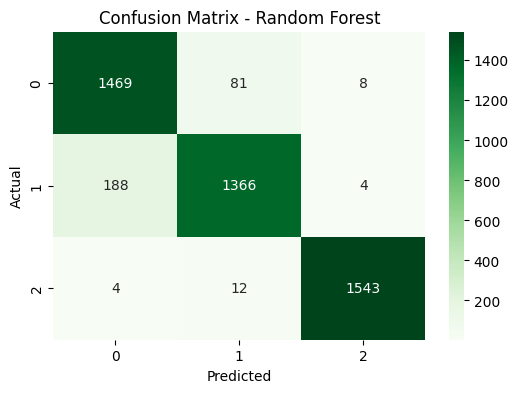

In [22]:
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


Confusion matrix Random Forest menunjukkan peningkatan performa yang signifikan dibandingkan Logistic Regression dalam mengklasifikasikan status penerimaan MBA.

Visualisasi memperlihatkan bahwa sebagian besar data pada setiap kelas berhasil diklasifikasikan dengan benar, ditunjukkan oleh nilai diagonal yang tinggi. Kesalahan klasifikasi antar kelas relatif lebih sedikit, termasuk pada kelas minoritas, yang sebelumnya sulit diprediksi oleh model baseline.

Hasil ini mengindikasikan bahwa Random Forest lebih mampu menangkap pola kompleks dan hubungan non-linear antar variabel dalam dataset. Dengan performa klasifikasi yang lebih seimbang antar kelas, Random Forest dinilai lebih sesuai untuk digunakan sebagai model utama dalam prediksi status penerimaan MBA.


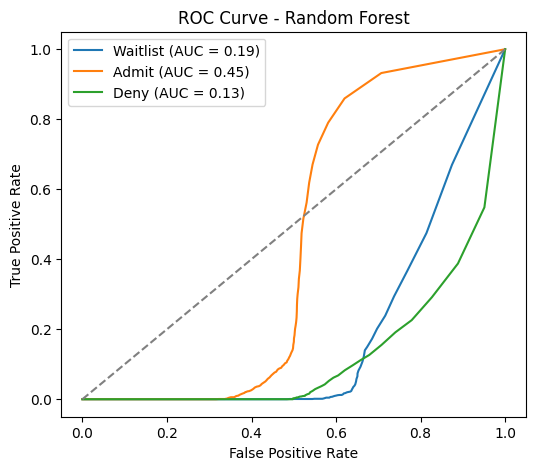

In [23]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binarisasi label untuk multi-class ROC
classes = y_test.unique()
y_test_bin = label_binarize(y_test, classes=classes)
y_score = rf.predict_proba(X_test)

plt.figure(figsize=(6,5))

for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{cls} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.show()


ROC Curve digunakan untuk mengevaluasi kemampuan model Random Forest dalam membedakan masing-masing kelas admission menggunakan pendekatan *one-vs-rest*. Setiap kurva merepresentasikan performa model dalam membedakan satu kelas terhadap kelas lainnya pada berbagai nilai threshold.

Berdasarkan hasil visualisasi, nilai Area Under Curve (AUC) pada masing-masing kelas menunjukkan variasi performa diskriminatif. Pada beberapa kelas, nilai AUC berada di bawah nilai ideal, yang mengindikasikan bahwa evaluasi ROC pada kasus multi-kelas dan dataset yang tidak seimbang memiliki keterbatasan dalam merepresentasikan performa model secara keseluruhan.

Meskipun demikian, hasil confusion matrix dan metrik klasifikasi lainnya menunjukkan bahwa model Random Forest tetap mampu melakukan klasifikasi dengan baik. Oleh karena itu, ROC Curve pada penelitian ini digunakan sebagai evaluasi tambahan dan tidak menjadi satu-satunya dasar penilaian performa model.


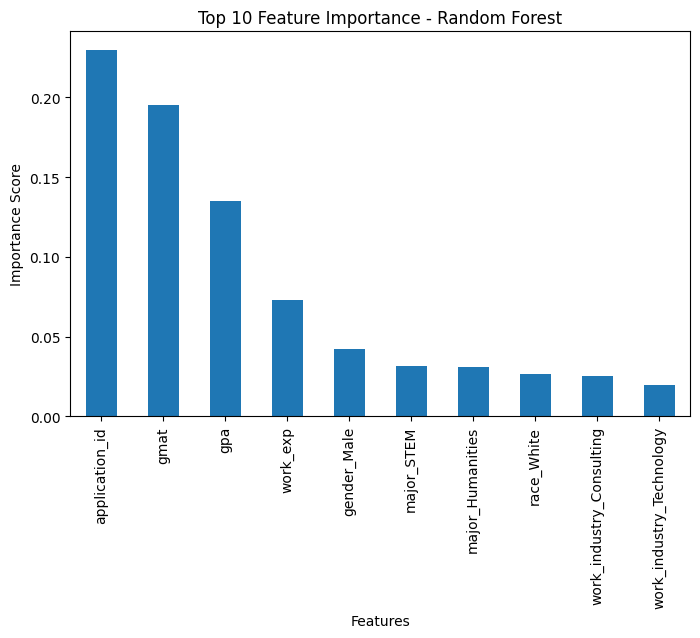

In [24]:
importances = rf.feature_importances_
feature_names = X_train.columns

feat_importance = pd.Series(importances, index=feature_names)
top_features = feat_importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
top_features.plot(kind='bar')
plt.title('Top 10 Feature Importance - Random Forest')
plt.ylabel('Importance Score')
plt.xlabel('Features')
plt.show()


Visualisasi feature importance menunjukkan sepuluh fitur teratas yang paling berkontribusi terhadap prediksi status penerimaan MBA oleh model Random Forest.

Hasil visualisasi memperlihatkan bahwa variabel akademik seperti **GMAT score** dan **GPA**, serta variabel profesional seperti **pengalaman kerja (work_exp)**, memiliki kontribusi yang signifikan dalam proses pengambilan keputusan model. Temuan ini konsisten dengan analisis statistik sebelumnya yang menunjukkan bahwa faktor akademik dan pengalaman kerja berperan penting dalam seleksi penerimaan MBA.

Selain itu, beberapa variabel demografis dan latar belakang pendidikan, seperti **gender**, **major**, dan **work industry**, juga memberikan kontribusi tambahan meskipun dengan tingkat kepentingan yang lebih rendah.

Perlu dicatat bahwa kemunculan **`application_id`** sebagai fitur dengan nilai importance tertinggi menunjukkan keterbatasan pendekatan feature importance berbasis *Decision Tree*, di mana model dapat menangkap pola yang bersifat artefaktual dari identitas data. Oleh karena itu, hasil feature importance ini digunakan sebagai alat interpretasi tambahan dan tidak diartikan sebagai faktor kausal dalam keputusan penerimaan MBA.


Secara keseluruhan, visualisasi pada bagian ini membantu memperkuat pemahaman terhadap performa dan interpretasi model Random Forest, sekaligus menunjukkan keterbatasan metode visualisasi dalam menjelaskan hubungan kausal antar variabel.
